In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# 시스템 패러미터
M = np.array([2,0,0,1]).reshape(2,2)  # 1층 질량 2, 2층 질량 1
K = np.array([3,-1,-1,1]).reshape(2,2) # 1층 기둥 강성 2, 2층 기둥 강성 1
c = np.array([0,0,0,0]).reshape(2,2)
nmode = len(M)

# 초기조건
x0 = 1
xdot0 = 1

icsx = np.vstack((x0,xdot0))






In [3]:
icsx

array([[1],
       [1]])

In [4]:
# 시간정의
dt = 0.01
Td = 30
time = np.arange(0,Td,dt)
nstep = len(time)

In [5]:
nstep

3000

In [6]:
# 고유값, 고유벡터

eigvalue, phi = np.linalg.eig(np.linalg.inv(M)@K)
eigvalue = np.diag(eigvalue)
print(eigvalue)
print(phi)

# np.linalg.eig는 인자를 1개만 받지만 내림차순으로 고유값을 계산함

[[2.  0. ]
 [0.  0.5]]
[[ 0.70710678  0.4472136 ]
 [-0.70710678  0.89442719]]


In [7]:
# 고유값을 오름차순으로 정렬
eigvalue, phi = np.linalg.eig(np.linalg.inv(M)@K)
eigvalue = np.diag(np.sort(eigvalue))
print(eigvalue)
print(phi)

[[0.5 0. ]
 [0.  2. ]]
[[ 0.70710678  0.4472136 ]
 [-0.70710678  0.89442719]]


In [8]:
# 고유진동수
wn = np.diag(np.sqrt(eigvalue))
print(wn)

[0.70710678 1.41421356]


In [9]:
np.sqrt(2)

np.float64(1.4142135623730951)

In [10]:
# 고유벡터의 열도 역순으로 재정렬
phi = phi[:, ::-1]
print(phi)

[[ 0.4472136   0.70710678]
 [ 0.89442719 -0.70710678]]


In [11]:
# 고유벡터의 정규화 1) 모달 매스로 정규화
phi_n1 = np.zeros_like(phi)
for j in range(nmode):
  modal_mass = phi[:,j].T @ M @ phi[:,j]
  phi_n1[:,j] = phi[:,j]/np.sqrt(modal_mass)

print("Eigenmode: \n",phi_n1)
print("Normalized Mass: \n", phi_n1.T@M@phi_n1)
print("Normalized Stiffness: \n", phi_n1.T@K@phi_n1)


Eigenmode: 
 [[ 0.40824829  0.57735027]
 [ 0.81649658 -0.57735027]]
Normalized Mass: 
 [[1.0000000e+00 2.1531457e-17]
 [2.1531457e-17 1.0000000e+00]]
Normalized Stiffness: 
 [[ 5.00000000e-01 -7.25009984e-17]
 [ 4.30629139e-17  2.00000000e+00]]


In [12]:
# 고유벡터의 정규화 2) 최상층변위를 1로 정규화
phi_n2 = np.zeros_like(phi)
for j in range(nmode):
  phi_n2[:,j] = phi[:,j]/phi[-1,j]

print("Eigenmode: \n",phi_n2)
print("Normalized Mass: \n", phi_n2.T@M@phi_n2)
print("Normalized Stiffness: \n", phi_n2.T@K@phi_n2)

Eigenmode: 
 [[ 0.5 -1. ]
 [ 1.   1. ]]
Normalized Mass: 
 [[1.5 0. ]
 [0.  3. ]]
Normalized Stiffness: 
 [[0.75 0.  ]
 [0.   6.  ]]


In [13]:
# 고유벡터의 정규화 3) 1층변위를 1로 정규화
phi_n3 = np.zeros_like(phi)
for j in range(nmode):
  phi_n3[:,j] = phi[:,j]/phi[0,j]

print("Eigenmode: \n",phi_n3)
print("Normalized Mass: \n", phi_n3.T@M@phi_n3)
print("Normalized Stiffness: \n", phi_n3.T@K@phi_n3)

Eigenmode: 
 [[ 1.  1.]
 [ 2. -1.]]
Normalized Mass: 
 [[6. 0.]
 [0. 3.]]
Normalized Stiffness: 
 [[3. 0.]
 [0. 6.]]


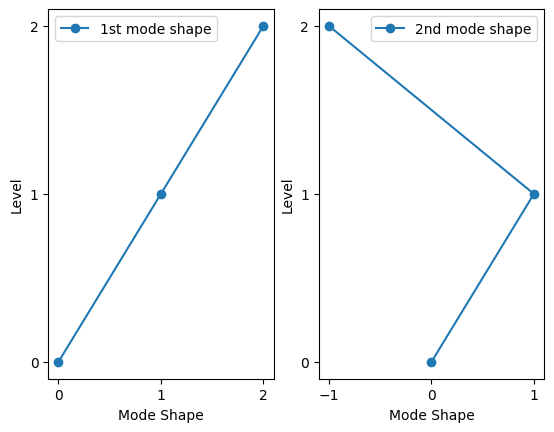

In [14]:
# 고유벡터 시각화
temp = np.zeros((1,nmode))
x = np.vstack((temp,phi_n3))
y = np.arange(nmode+1)

plt.subplot(1, 2, 1)
plt.plot(x[:,0], y, marker='o',label='1st mode shape')
plt.xlabel('Mode Shape')
plt.ylabel('Level')
plt.legend()
plt.xticks(x[:,0])
plt.yticks(y)

plt.subplot(1, 2, 2)
plt.plot(x[:,1], y, marker='o',label = '2nd mode shape')
plt.xlabel('Mode Shape')
plt.ylabel('Level')
plt.legend()
plt.xticks(x[:,1])
plt.yticks(y)

plt.show()

In [15]:
# 초기조건
ics_eta= np.linalg.inv(phi_n3)@icsx
print(ics_eta)

[[0.66666667]
 [0.33333333]]


In [16]:
# 모드 응답
eta = np.zeros((nstep,nmode))

for i in range(nmode):
  eta[:,i] = ics_eta[0]*np.cos(wn[i]*time)+(ics_eta[1]/wn[i])*np.sin(wn[i]*time)




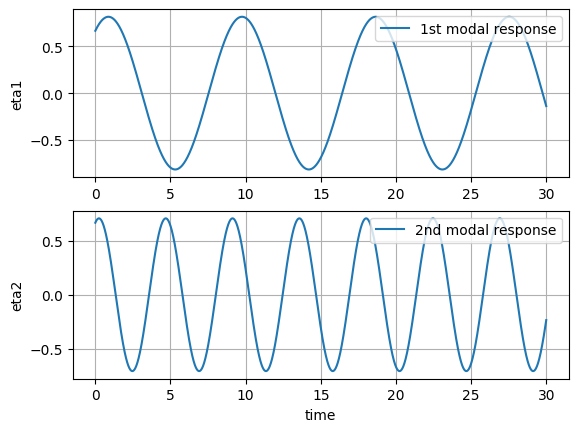

In [17]:
# 모드 응답 시각화

plt.subplot(2,1,1)
plt.plot(time,eta[:,0],label = '1st modal response')
plt.legend(loc='upper right')
plt.ylabel('eta1')
plt.grid()

plt.subplot(2,1,2)
plt.plot(time,eta[:,1],label = '2nd modal response')
plt.legend(loc='upper right')
plt.xlabel('time')
plt.ylabel('eta2')
plt.grid()

plt.show()


In [18]:
# 글로벌 좌표계 응답 X
X = phi_n3@eta.T


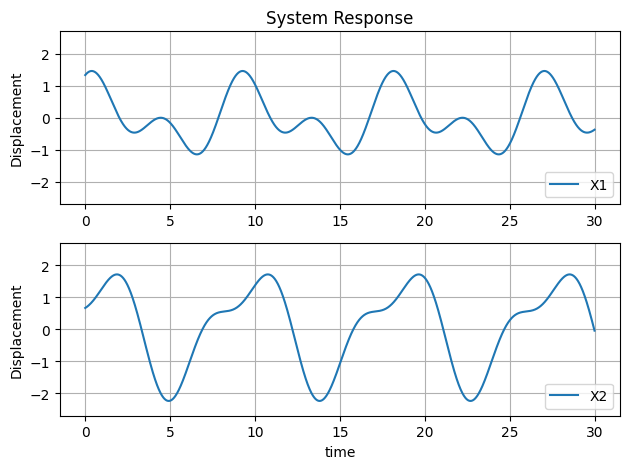

In [19]:
# 각 층 응답 시각화

plt.subplot(2,1,1)
plt.plot(time,X[0,:],label='X1')
plt.ylabel('Displacement')
plt.ylim(-2.7,2.7)
plt.legend(loc='lower right')
plt.title('System Response')

plt.grid()

plt.subplot(2,1,2)
plt.plot(time,X[1,:], label = 'X2')
plt.xlabel('time')
plt.ylabel('Displacement')
plt.legend(loc='lower right')
plt.ylim(-2.7,2.7)
plt.grid()

plt.tight_layout()
plt.show()